# py4DSTEM Final Complete Workflow: Bragg Disks → Calibration → ACOM Orientation Map → Optional Strain
适用目标：
- 任意 4D-STEM 数据的通用处理模板；
- 支持读取已有 calibration、从多晶标准样品 transfer 校正、或从目标数据直接校正；
- 支持 ACOM orientation map；
- 可选输出 `.ang`、保存中间结果、进行 strain map。
核心原则：
1. Bragg disk detection 可以先在 raw detector pixel 坐标中完成；
2. ACOM 至少需要 `origin + Q pixel size`，正式结果建议加入 `ellipse`；
3. strain / COM / DPC 若要定量解释方向，必须重视 `QR rotation`；
4. 多晶标准样品适合校正 `Q pixel size + ellipse`，不建议盲目 transfer `origin`；
5. 单晶/少数取向样品不建议直接拟合 ellipse，优先用多晶标准。



## 0. Imports



In [1]:
import os
import pickle
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import py4DSTEM
from py4DSTEM.visualize import show

print("py4DSTEM version:", py4DSTEM.__version__)
try:
    py4DSTEM.check_config()
except Exception as exc:
    print("py4DSTEM.check_config() skipped/failed:", repr(exc))




py4DSTEM version: 0.14.19
Checking Module Dependencies
 All Dependencies for Base are Installed 
 Not All Dependencies for Ipyparallel are Installed
 Not All Dependencies for Cuda are Installed
 Not All Dependencies for Acom are Installed
 Not All Dependencies for Aiml are Installed
 Not All Dependencies for Aiml-cuda are Installed
 Not All Dependencies for Numba are Installed


## 1. User configuration
只需要优先修改这一节。其它代码尽量保持不动。



In [ ]:
# -----------------------------
# 1.1 Data path and tree names
# -----------------------------
DATA_FILE = r"../data/sim_Au_data_all_binned.h5"
DATA_GROUP = "4DSTEM_simulation"

TARGET_DATACUBE_NAME = "4DSTEM_AuNanoplatelet"
POLY_DATACUBE_NAME = "4DSTEM_polyAu"          # optional polycrystalline standard
VACUUM_PROBE_NAME = "vacuum_probe"            # optional probe from file
DEFOCUSED_CBED_NAME = "defocused_CBED"        # optional QR rotation reference

# -----------------------------
# 1.2 Main switches
# -----------------------------
RUN_LOAD_DATA = True
RUN_BASIC_VISUALIZATION = True
RUN_PROBE_PREPARATION = True
RUN_SINGLE_POSITION_TEST = True
RUN_SELECTED_POSITION_TEST = True
RUN_FULL_BRAGG_DETECTION = True
RUN_CALIBRATION = True
RUN_ACOM_ORIENTATION = True
RUN_SAVE_RESULTS = True
RUN_STRAIN_OPTIONAL = False

SHOW_FIGS = True
CUDA = False

# -----------------------------
# 1.3 Calibration strategy
# -----------------------------
# Options:
#   "read_existing"   : trust existing calibration, only validate and set flags
#   "poly_transfer"   : use polycrystal standard to fit/transfer Q pixel size + ellipse
#   "target_direct"   : fit origin / ellipse / Q pixel size from target itself
#   "mixed"           : target origin + poly Q pixel size/ellipse, recommended when poly exists
CALIBRATION_STRATEGY = "mixed"

ANALYSIS_TARGET = "ACOM"
# Options: "preview", "ACOM", "strain", "flowline", "COM", "virtual"

# What to transfer from poly standard to target.
TRANSFER_Q_PIXEL_SIZE = True
TRANSFER_ELLIPSE = True
TRANSFER_ORIGIN = False       # usually False
TRANSFER_ROTATION = False     # usually False unless proven identical

# Target origin fitting is usually needed even when using poly standard.
DO_TARGET_MEASURE_ORIGIN = True
DO_TARGET_FIT_ORIGIN = True

# Direct target ellipse/Q calibration: only use when target has full rings / reliable indexed peaks.
DO_TARGET_FIT_ELLIPSE = False
DO_TARGET_CALIBRATE_Q_PIXEL = False

# Poly standard calibration: use if poly standard exists.
DO_POLY_BRAGG_DETECTION = True
DO_POLY_MEASURE_ORIGIN = True
DO_POLY_FIT_ORIGIN = True
DO_POLY_FIT_ELLIPSE = True
DO_POLY_CALIBRATE_Q_PIXEL = True

# Ellipse fitting radial ranges, in BVM pixel units. Must be adjusted from your BVM.
TARGET_ELLIPSE_Q_RANGE = (290, 360)
POLY_ELLIPSE_Q_RANGE = (290, 360)

# Use ellipse / rotation during downstream analysis if available.
USE_ELLIPSE_IF_AVAILABLE = True
USE_ROTATION_IF_AVAILABLE_FOR_ACOM = False
USE_ROTATION_IF_AVAILABLE_FOR_STRAIN = True

# Manual QR rotation. Recommended to determine with defocused CBED / dedicated method.
DO_SET_QR_ROTATION_MANUAL = False
QR_ROTATION_DEGREES = -83

# -----------------------------
# 1.4 Probe source
# -----------------------------
USE_PROBE_FROM_FILE = True
# If no vacuum_probe exists or USE_PROBE_FROM_FILE=False, use an ROI on VBF.
VACUUM_PROBE_ROI_SLICES = (slice(15, 20), slice(15, 20))

# Probe kernel settings
PROBE_KERNEL_MODE = "sigmoid"
PROBE_KERNEL_OUTER_FACTOR = 2.0
SHOW_KERNEL_R = 24

# -----------------------------
# 1.5 Bragg disk detection parameters
# -----------------------------
BRAGG_DETECT_PARAMS = {
    "minAbsoluteIntensity": 2,
    "minRelativeIntensity": 0,
    "minPeakSpacing": 18,
    "edgeBoundary": 2,
    "sigma": 0,
    "maxNumPeaks": 100,
    "subpixel": "poly",
    "corrPower": 1.0,
}

# selected positions for diagnostic plots
SELECTED_RXS = (36, 15, 11, 59, 32, 34)
SELECTED_RYS = (9, 15, 31, 39, 20, 68)
SELECTED_COLORS = ["r", "limegreen", "c", "g", "orange", "violet"]

# BVM visualization
BVM_SAMPLING = 8

# -----------------------------
# 1.6 Reference crystal for Au / fcc example
# -----------------------------
# For non-Au data, change this section.
USE_CIF_FOR_ACOM = False
CIF_PATH = r"D:\Downloads\Au.cif"

A_LAT = 4.08          # Angstrom, fcc Au approximately 4.078–4.08 Å
ATOM_NUM = 79         # Au
K_MAX = 1.5           # inverse Angstroms
Q_PIXEL_SIZE_GUESS = 0.02
Q_PIXEL_UNITS = "A^-1"

# -----------------------------
# 1.7 Orientation plan and matching
# -----------------------------
ACCEL_VOLTAGE = 300e3
ZONE_AXIS_RANGE = "auto"       # "auto", "full", "half", or ndarray
ANGLE_STEP_ZONE_AXIS = 2.0
ANGLE_STEP_IN_PLANE = 2.0
CORR_KERNEL_SIZE = 0.08
SIGMA_EXCITATION_ERROR = 0.02
POWER_RADIAL = 1.0
POWER_INTENSITY = 0.0
POWER_INTENSITY_EXPERIMENT = 0.0

NUM_MATCHES_RETURN = 1          # use 1 for final map; 2/3 for diagnostic multi-match check
MIN_ANGLE_BETWEEN_MATCHES_DEG = 5
MIN_NUMBER_PEAKS = 3
INVERSION_SYMMETRY = True
CORR_RANGE = np.array([0, 2])

# -----------------------------
# 1.8 Save / export
# -----------------------------
OUTPUT_DIR = Path("./py4dstem_outputs")
SAVE_BRAGGVECTORS_PICKLE = True
SAVE_ORIENTATION_PICKLE = True
SAVE_ANG_FILE = False           # requires orix; set True if installed
ANG_PIXEL_SIZE = 1.0            # real-space scan step, e.g. nm per pixel
ANG_PIXEL_UNITS = "nm"

# -----------------------------
# 1.9 Optional strain mapping
# -----------------------------
STRAIN_REFERENCE_MODE = "roi_vectors"
# Options: "roi_vectors", "roi_mask", "auto_valid", "manual"
STRAIN_REF_ROI_SLICES = (slice(34, 42), slice(8, 16))
STRAIN_COORDINATE_ROTATION = -21.5
STRAIN_VRANGE = [-6.0, 6.0]
THETA_VRANGE = [-2.0, 2.0]
STRAIN_LAYOUT = "square"




## 2. Helper functions



In [ ]:
def tree_get(root_obj, name):
    """Robustly get a node from a py4DSTEM tree."""
    try:
        return root_obj.tree(name)
    except Exception:
        try:
            return root_obj.tree(get=name)
        except Exception as exc:
            raise KeyError(f"Could not find tree node: {name}") from exc


def exists_tree(root_obj, name):
    try:
        tree_get(root_obj, name)
        return True
    except Exception:
        return False


def safe_show(*args, **kwargs):
    if SHOW_FIGS:
        return show(*args, **kwargs)
    return None


def _get_cal(obj):
    if obj is None:
        return None
    return obj.calibration if hasattr(obj, "calibration") else obj


def _safe_call(obj, method_name, *args, default=None, **kwargs):
    if obj is None or not hasattr(obj, method_name):
        return default
    try:
        return getattr(obj, method_name)(*args, **kwargs)
    except Exception:
        return default


def get_origin(obj):
    return _safe_call(_get_cal(obj), "get_origin", default=None)


def set_origin(obj, value):
    cal = _get_cal(obj)
    if cal is None or value is None:
        return False
    if hasattr(cal, "set_origin"):
        cal.set_origin(value)
        return True
    raise AttributeError("Calibration object has no set_origin method.")


def get_q_pixel_size(obj):
    return _safe_call(_get_cal(obj), "get_Q_pixel_size", default=None)


def get_q_pixel_units(obj):
    return _safe_call(_get_cal(obj), "get_Q_pixel_units", default=None)


def set_q_pixel(obj, size, units="A^-1"):
    cal = _get_cal(obj)
    if cal is None or size is None:
        return False
    if not hasattr(cal, "set_Q_pixel_size"):
        raise AttributeError("Calibration object has no set_Q_pixel_size method.")
    cal.set_Q_pixel_size(size)
    if units is not None and hasattr(cal, "set_Q_pixel_units"):
        cal.set_Q_pixel_units(units)
    return True


def get_ellipse(obj):
    cal = _get_cal(obj)
    return _safe_call(cal, "get_ellipse", default=None)


def _value_len(value):
    """Return len(value) when value is sequence-like; otherwise None."""
    try:
        return len(value)
    except Exception:
        return None


def set_ellipse(obj, value):
    """Set ellipse calibration robustly across py4DSTEM versions.

    Important distinction:
    - Calibration.set_ellipse(x) expects a 3-tuple: (a, b, theta).
    - fit_ellipse_1D(...) usually returns a longer p_ellipse parameterization.
      That result should be passed to Calibration.set_p_ellipse(...), not set_ellipse(...).

    This helper chooses set_p_ellipse for non-3-length values and set_ellipse
    for 3-length values, falling back gracefully when one method is absent.
    """
    cal = _get_cal(obj)
    if cal is None or value is None:
        return False

    n = _value_len(value)

    # p_ellipse returned by fit_ellipse_1D is not the same as (a, b, theta).
    if n is not None and n != 3 and hasattr(cal, "set_p_ellipse"):
        cal.set_p_ellipse(value)
        return True

    if hasattr(cal, "set_ellipse"):
        cal.set_ellipse(value)
        return True

    if hasattr(cal, "set_p_ellipse"):
        cal.set_p_ellipse(value)
        return True

    raise AttributeError("Calibration object has neither set_ellipse nor set_p_ellipse.")


def set_p_ellipse(obj, value):
    """Explicitly set py4DSTEM p_ellipse parameters from fit_ellipse_1D."""
    cal = _get_cal(obj)
    if cal is None or value is None:
        return False
    if hasattr(cal, "set_p_ellipse"):
        cal.set_p_ellipse(value)
        return True
    # Last-resort fallback for unusual versions; will only work if value is (a,b,theta).
    if hasattr(cal, "set_ellipse"):
        cal.set_ellipse(value)
        return True
    raise AttributeError("Calibration object has neither set_p_ellipse nor set_ellipse.")


def get_qr_rotation(obj):
    cal = _get_cal(obj)
    if cal is None:
        return None
    for name in ("get_QR_rotation_degrees", "get_QR_rotation", "get_QR_rotflip"):
        out = _safe_call(cal, name, default=None)
        if out is not None:
            return out
    return None


def set_qr_rotation_degrees(obj, degrees):
    cal = _get_cal(obj)
    if cal is None or degrees is None:
        return False
    if hasattr(cal, "set_QR_rotation_degrees"):
        cal.set_QR_rotation_degrees(degrees)
        return True
    if hasattr(cal, "set_QR_rotation"):
        cal.set_QR_rotation(degrees)
        return True
    raise AttributeError("Calibration object has no QR rotation setter.")


def has_origin(obj):
    return get_origin(obj) is not None


def has_q_pixel(obj):
    return get_q_pixel_size(obj) is not None


def has_ellipse(obj):
    return get_ellipse(obj) is not None


def has_rotation(obj):
    return get_qr_rotation(obj) is not None


def print_calibration_report(obj, name="object"):
    cal = _get_cal(obj)
    print(f"\n===== Calibration report: {name} =====")
    if cal is None:
        print("No calibration object found.")
        return
    print("R pixel size:", _safe_call(cal, "get_R_pixel_size", default=None))
    print("R pixel units:", _safe_call(cal, "get_R_pixel_units", default=None))
    print("Q pixel size:", get_q_pixel_size(cal))
    print("Q pixel units:", get_q_pixel_units(cal))
    print("origin:", get_origin(cal))
    print("ellipse:", get_ellipse(cal))
    print("QR rotation / rotflip:", get_qr_rotation(cal))
    if hasattr(obj, "calstate"):
        print("calstate:", obj.calstate)
    print("flags:", {
        "origin": has_origin(cal),
        "q_pixel": has_q_pixel(cal),
        "ellipse": has_ellipse(cal),
        "rotation": has_rotation(cal),
    })


def compare_qshape(*named_objects):
    print("\n===== Qshape check =====")
    for item in named_objects:
        if item is None:
            continue
        if isinstance(item, tuple):
            name, obj = item
        else:
            name, obj = getattr(item, "name", "object"), item
        print(f"{name}: Qshape={getattr(obj, 'Qshape', None)}, shape={getattr(obj, 'shape', None)}")


def copy_calibration_values(source, target, q_pixel_size=True, q_pixel_units=True,
                            ellipse=True, origin=False, rotation=False, verbose=True):
    src = _get_cal(source)
    tgt = _get_cal(target)
    if src is None or tgt is None:
        raise ValueError("source and target must have calibration objects.")

    if q_pixel_size:
        size = get_q_pixel_size(src)
        units = get_q_pixel_units(src) if q_pixel_units else get_q_pixel_units(tgt)
        if size is not None:
            set_q_pixel(tgt, size, units)
            if verbose:
                print(f"Transferred Q pixel size: {size} {units}/pixel")
        elif verbose:
            print("Skipped Q pixel size: source has no Q pixel size.")

    if ellipse:
        ell = get_ellipse(src)
        if ell is not None:
            set_ellipse(tgt, ell)
            if verbose:
                print(f"Transferred ellipse: {ell}")
        elif verbose:
            print("Skipped ellipse: source has no ellipse.")

    if origin:
        ori = get_origin(src)
        if ori is not None:
            set_origin(tgt, ori)
            if verbose:
                print(f"Transferred origin: {ori}")
        elif verbose:
            print("Skipped origin: source has no origin.")

    if rotation:
        rot = get_qr_rotation(src)
        if rot is not None and np.isscalar(rot):
            set_qr_rotation_degrees(tgt, rot)
            if verbose:
                print(f"Transferred QR rotation: {rot}")
        elif verbose:
            print("Skipped rotation: source has no scalar QR rotation.")


def sync_datacube_to_braggvectors(datacube_obj, bvs_obj, transfer_origin=True, transfer_rotation=False):
    copy_calibration_values(
        source=datacube_obj,
        target=bvs_obj,
        q_pixel_size=True,
        q_pixel_units=True,
        ellipse=True,
        origin=transfer_origin,
        rotation=transfer_rotation,
        verbose=False,
    )


def choose_setcal_flags(bvs_obj, analysis_target="ACOM", use_ellipse=True, use_rotation=False):
    target = analysis_target.lower()
    cal = bvs_obj.calibration

    if target in ("preview", "raw"):
        return dict(center=False, ellipse=False, pixel=False, rotate=False)

    if target in ("virtual", "vbf", "adf"):
        return dict(center=has_origin(cal), ellipse=use_ellipse and has_ellipse(cal), pixel=has_q_pixel(cal), rotate=False)

    if target in ("acom", "orientation", "orientation_map"):
        missing = []
        if not has_origin(cal):
            missing.append("origin / center")
        if not has_q_pixel(cal):
            missing.append("Q pixel size")
        if missing:
            raise RuntimeError("ACOM requires: " + ", ".join(missing))
        return dict(center=True, ellipse=use_ellipse and has_ellipse(cal), pixel=True, rotate=use_rotation and has_rotation(cal))

    if target in ("strain", "strain_map"):
        missing = []
        for label, fn in [("origin / center", has_origin), ("Q pixel size", has_q_pixel), ("ellipse", has_ellipse), ("QR rotation", has_rotation)]:
            if not fn(cal):
                missing.append(label)
        if missing:
            raise RuntimeError("Strain mapping strongly requires: " + ", ".join(missing))
        return dict(center=True, ellipse=True, pixel=True, rotate=True)

    if target in ("flowline", "polar"):
        missing = []
        if not has_origin(cal):
            missing.append("origin / center")
        if not has_ellipse(cal):
            missing.append("ellipse")
        if missing:
            raise RuntimeError("Flowline / polar requires: " + ", ".join(missing))
        return dict(center=True, ellipse=True, pixel=has_q_pixel(cal), rotate=use_rotation and has_rotation(cal))

    if target in ("com", "dpc"):
        missing = []
        if not has_origin(cal):
            missing.append("origin / center")
        if not has_rotation(cal):
            missing.append("QR rotation")
        if missing:
            raise RuntimeError("COM / DPC direction interpretation requires: " + ", ".join(missing))
        return dict(center=True, ellipse=False, pixel=False, rotate=True)

    raise ValueError(f"Unknown analysis target: {analysis_target}")


def apply_setcal(bvs_obj, analysis_target="ACOM"):
    use_rot = USE_ROTATION_IF_AVAILABLE_FOR_STRAIN if analysis_target.lower().startswith("strain") else USE_ROTATION_IF_AVAILABLE_FOR_ACOM
    flags = choose_setcal_flags(
        bvs_obj,
        analysis_target=analysis_target,
        use_ellipse=USE_ELLIPSE_IF_AVAILABLE,
        use_rotation=use_rot,
    )
    print("Applying braggvectors.setcal:", flags)
    bvs_obj.setcal(**flags)
    print("calstate:", bvs_obj.calstate)
    return flags


def make_fcc_crystal(a_lat=A_LAT, atom_num=ATOM_NUM):
    pos = np.array([
        [0.0, 0.0, 0.0],
        [0.0, 0.5, 0.5],
        [0.5, 0.0, 0.5],
        [0.5, 0.5, 0.0],
    ])
    return py4DSTEM.process.diffraction.Crystal(pos, atom_num, a_lat)


def build_reference_crystal(use_cif=False, cif_path=CIF_PATH):
    if use_cif and Path(cif_path).exists():
        print(f"Loading crystal from CIF: {cif_path}")
        return py4DSTEM.process.diffraction.Crystal.from_CIF(cif_path)
    print("Using manual fcc reference crystal.")
    return make_fcc_crystal(A_LAT, ATOM_NUM)


def calculate_structure_factors_if_needed(crystal_obj, k_max=K_MAX):
    try:
        crystal_obj.calculate_structure_factors(k_max=k_max, tol_structure_factor=1e-4)
    except TypeError:
        crystal_obj.calculate_structure_factors(k_max)
    return crystal_obj


def calibrate_origin_from_bvs(bvs_obj, label="target"):
    if DO_TARGET_MEASURE_ORIGIN or DO_POLY_MEASURE_ORIGIN:
        print(f"\nMeasuring origin for {label}...")
        qx0_meas, qy0_meas, mask_meas = bvs_obj.measure_origin()
        if SHOW_FIGS:
            show([qx0_meas, qy0_meas], cmap="RdBu", mask=mask_meas, show_cbar=True,
                 title=[f"{label} qx0 measured", f"{label} qy0 measured"])
    print(f"Fitting origin for {label}...")
    qx0_fit, qy0_fit, qx0_residuals, qy0_residuals = bvs_obj.fit_origin()
    print_calibration_report(bvs_obj, f"{label} after origin fit")
    return qx0_fit, qy0_fit, qx0_residuals, qy0_residuals


def show_bvm(bvs_obj, label="BVM", sampling=BVM_SAMPLING, mode="cal", vmax=0.99):
    bvm = bvs_obj.histogram(mode=mode, sampling=sampling)
    if SHOW_FIGS:
        kwargs = dict(scaling="log", title=label)
        if hasattr(bvm, "origin"):
            kwargs["circle"] = {"center": bvm.origin, "R": 4 * sampling, "fill": False, "linewidth": 1}
        show(bvm, **kwargs)
    return bvm


def compare_raw_cal_bvm(bvs_obj, label="target", sampling=BVM_SAMPLING):
    if not SHOW_FIGS:
        return None, None
    bvm_raw = bvs_obj.histogram(mode="raw", sampling=sampling)
    bvm_cal = bvs_obj.histogram(mode="cal", sampling=sampling)
    show([bvm_raw, bvm_cal], vmax=0.999999, scaling="log", title=[f"{label} raw", f"{label} cal"])
    return bvm_raw, bvm_cal


def fit_ellipse_from_bvm(bvs_obj, q_range, label="target"):
    if not has_origin(bvs_obj.calibration):
        raise RuntimeError(f"Fit origin before ellipse fitting for {label}.")
    bvs_obj.setcal(center=True, ellipse=False, pixel=False, rotate=False)
    bvm_c = bvs_obj.histogram(sampling=BVM_SAMPLING)
    if SHOW_FIGS:
        py4DSTEM.show(
            bvm_c,
            cmap="gray",
            intensity_range="absolute",
            scaling="log",
            vmin=0,
            vmax=1e2,
            annulus={"center": bvm_c.origin, "radii": q_range, "fill": True, "color": "r", "alpha": 0.3},
            title=f"{label} ellipse fitting annulus",
        )
    p_ellipse = py4DSTEM.process.calibration.fit_ellipse_1D(
        bvm_c,
        center=bvm_c.origin,
        fitradii=q_range,
    )
    if SHOW_FIGS:
        py4DSTEM.visualize.show_elliptical_fit(
            bvm_c,
            q_range,
            p_ellipse,
            cmap="gray",
            intensity_range="absolute",
            vmin=0,
            vmax=1e2,
        )
    # fit_ellipse_1D returns p_ellipse, so use set_p_ellipse, not set_ellipse.
    set_p_ellipse(bvs_obj.calibration, p_ellipse)
    print(f"{label} fitted p_ellipse:", p_ellipse)
    print(f"{label} converted ellipse:", get_ellipse(bvs_obj.calibration))
    return p_ellipse


def calibrate_q_pixel_from_crystal(bvs_obj, crystal_obj, label="target",
                                   q_pixel_guess=Q_PIXEL_SIZE_GUESS,
                                   q_units=Q_PIXEL_UNITS,
                                   k_max=K_MAX,
                                   bragg_k_power=2.0):
    calculate_structure_factors_if_needed(crystal_obj, k_max)
    if SHOW_FIGS:
        crystal_obj.plot_scattering_intensity()

    set_q_pixel(bvs_obj.calibration, q_pixel_guess, q_units)
    bvs_obj.setcal(
        center=has_origin(bvs_obj.calibration),
        ellipse=has_ellipse(bvs_obj.calibration),
        pixel=True,
        rotate=False,
    )

    if SHOW_FIGS:
        crystal_obj.plot_scattering_intensity(bragg_peaks=bvs_obj, bragg_k_power=bragg_k_power)

    print(f"Calibrating Q pixel size for {label}...")
    result = crystal_obj.calibrate_pixel_size(
        bragg_peaks=bvs_obj,
        bragg_k_power=bragg_k_power,
        plot_result=SHOW_FIGS,
        returnfig=True,
    )

    bvs_fitted = None
    fig = None
    ax = None
    try:
        bvs_fitted, (fig, ax) = result
    except Exception:
        bvs_fitted = result

    # Some versions update bvs_obj in place; some return fitted copy.
    if hasattr(bvs_fitted, "calibration"):
        copy_calibration_values(bvs_fitted, bvs_obj, q_pixel_size=True, q_pixel_units=True,
                                ellipse=False, origin=False, rotation=False, verbose=False)

    print_calibration_report(bvs_obj, f"{label} after Q pixel calibration")
    return bvs_obj, fig, ax


def get_reference_crystal_for_calibration():
    """Build the calibration crystal only when a calibration step needs it."""
    global crystal_for_calibration
    if 'crystal_for_calibration' not in globals() or crystal_for_calibration is None:
        crystal_for_calibration = build_reference_crystal(use_cif=False)
    return crystal_for_calibration


def get_existing_poly_braggvectors(default=None):
    """Reuse a precomputed poly BraggVectors object when one is already available."""
    candidate = globals().get('poly_braggvectors', default)
    if candidate is not None:
        return candidate
    if 'root' in globals() and exists_tree(root, 'poly_braggvectors'):
        return tree_get(root, 'poly_braggvectors')
    return None


def calibrate_poly_standard(poly_dc_obj=None, kernel_obj=None, existing_bvs=None, crystal_obj=None):
    """Run poly-standard calibration once, reusing existing BraggVectors when possible."""
    bvs_obj = existing_bvs if existing_bvs is not None else get_existing_poly_braggvectors()

    if bvs_obj is None:
        if poly_dc_obj is None:
            print("No poly_datacube available. Falling back to target/direct calibration where enabled.")
            return None
        if not DO_POLY_BRAGG_DETECTION:
            raise RuntimeError(
                "DO_POLY_BRAGG_DETECTION=False but no existing poly_braggvectors was provided."
            )
        if kernel_obj is None:
            raise RuntimeError("Poly Bragg disk detection requires a probe kernel.")
        print("Detecting poly Bragg disks...")
        bvs_obj = find_bragg_disks_for_datacube(
            poly_dc_obj,
            kernel_obj,
            name="poly_braggvectors",
            full=True,
        )
    else:
        print("Using existing poly_braggvectors.")

    bvs_obj.setcal(center=False, ellipse=False, pixel=False, rotate=False)

    if DO_POLY_MEASURE_ORIGIN:
        print("Measuring poly origin...")
        qx0_meas, qy0_meas, mask_meas = bvs_obj.measure_origin()
        if SHOW_FIGS:
            show([qx0_meas, qy0_meas], cmap="RdBu", mask=mask_meas, show_cbar=True,
                 title=["poly qx0 measured", "poly qy0 measured"])

    if DO_POLY_FIT_ORIGIN:
        print("Fitting poly origin...")
        bvs_obj.fit_origin()

    if DO_POLY_FIT_ELLIPSE:
        fit_ellipse_from_bvm(bvs_obj, POLY_ELLIPSE_Q_RANGE, label="poly")

    if DO_POLY_CALIBRATE_Q_PIXEL:
        calibrate_q_pixel_from_crystal(
            bvs_obj,
            crystal_obj if crystal_obj is not None else get_reference_crystal_for_calibration(),
            label="poly",
            q_pixel_guess=Q_PIXEL_SIZE_GUESS,
            q_units=Q_PIXEL_UNITS,
            k_max=K_MAX,
            bragg_k_power=2.0,
        )

    print_calibration_report(bvs_obj, "poly braggvectors calibrated")
    if SHOW_FIGS:
        compare_raw_cal_bvm(bvs_obj, label="poly", sampling=BVM_SAMPLING)
    return bvs_obj


def print_fcc_q_values(a_lat=A_LAT, hkls=((1,1,1),(2,0,0),(2,2,0),(3,1,1),(2,2,2),(4,0,0))):
    print(f"\nFCC reference q values for a = {a_lat} Å, q = 1/d:")
    for hkl in hkls:
        q = np.sqrt(sum(v*v for v in hkl)) / a_lat
        print(f"  {hkl}: {q:.4f} A^-1")


def find_bragg_disks_for_datacube(dc_obj, kernel_obj, name="braggvectors", full=True):
    if full:
        bvs = dc_obj.find_Bragg_disks(
            template=kernel_obj,
            data=None,
            CUDA=CUDA,
            name=name,
            **BRAGG_DETECT_PARAMS,
        )
        print(f"{name} type:", type(bvs))
        return bvs

    rx = dc_obj.Rshape[0] // 2
    ry = dc_obj.Rshape[1] // 2
    qpoints = dc_obj.find_Bragg_disks(template=kernel_obj, data=(rx, ry), **BRAGG_DETECT_PARAMS)
    print("scan position:", rx, ry)
    print("detected peaks:", len(qpoints.data))
    if SHOW_FIGS:
        py4DSTEM.show(
            dc_obj.data[rx, ry],
            scaling="log",
            points={"x": qpoints.data["qx"], "y": qpoints.data["qy"], "s": 40},
            title=f"Detected Bragg disks at ({rx}, {ry})",
        )
    return qpoints




## 3. Load data



In [4]:
if RUN_LOAD_DATA:
    DATA_FILE = str(DATA_FILE)
    if not Path(DATA_FILE).exists():
        raise FileNotFoundError(
            f"DATA_FILE not found: {DATA_FILE}\n"
            "Please edit DATA_FILE in the configuration section."
        )

    py4DSTEM.print_h5_tree(DATA_FILE)
    root = py4DSTEM.read(filepath=DATA_FILE, datapath=DATA_GROUP, tree=True)
    print(root)

    datacube = tree_get(root, TARGET_DATACUBE_NAME)
    print("Target datacube:", datacube)

    poly_datacube = None
    if POLY_DATACUBE_NAME and exists_tree(root, POLY_DATACUBE_NAME):
        poly_datacube = tree_get(root, POLY_DATACUBE_NAME)
        print("Poly datacube:", poly_datacube)

    defocused_cbed = None
    if DEFOCUSED_CBED_NAME and exists_tree(root, DEFOCUSED_CBED_NAME):
        defocused_cbed = tree_get(root, DEFOCUSED_CBED_NAME)
        print("Defocused CBED:", defocused_cbed)

compare_qshape(("target", datacube), ("poly", poly_datacube if 'poly_datacube' in globals() else None))
print_calibration_report(datacube, "target datacube initial")




/
|---4DSTEM_simulation
    |---4DSTEM_AuNanoplatelet
    |---4DSTEM_polyAu
    |---defocused_CBED
    |---vacuum_probe


Root( A Node called '4DSTEM_simulation', containing the following top-level objects in its tree:

          4DSTEM_AuNanoplatelet    	 (DataCube)
          4DSTEM_polyAu            	 (DataCube)
          defocused_CBED           	 (DiffractionSlice)
          vacuum_probe             	 (DiffractionSlice)
)
Target datacube: DataCube( A 4-dimensional array of shape (100, 84, 125, 125) called '4DSTEM_AuNanoplatelet',
          with dimensions:

              Rx = [0,1,2,...] pixels
              Ry = [0,1,2,...] pixels
              Qx = [0,1,2,...] pixels
              Qy = [0,1,2,...] pixels
)
Poly datacube: DataCube( A 4-dimensional array of shape (100, 84, 125, 125) called '4DSTEM_polyAu',
          with dimensions:

              Rx = [0,1,2,...] pixels
              Ry = [0,1,2,...] pixels
              Qx = [0,1,2,...] pixels
              Qy = [0,1,2,...] pixel

## 4. Basic visualization: mean DP, probe size, VBF/VADF



probe radius: 5.113302983166629
origin x0: 63.49003004201246
origin y0: 63.29708847195704


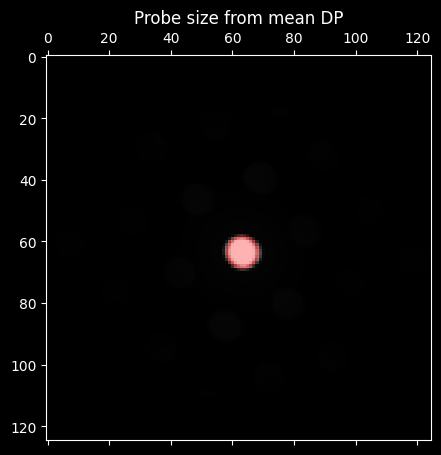

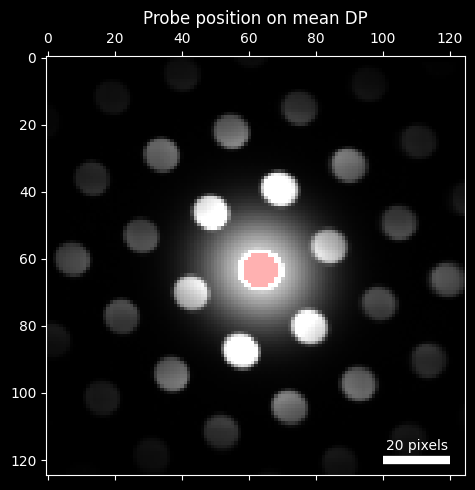

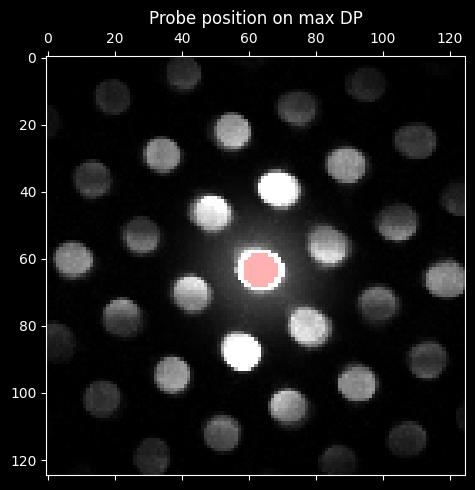

100%|██████████| 8400/8400 [00:00<00:00, 49996.53it/s]



===== Calibration report: target datacube after basic visualization =====
R pixel size: 1
R pixel units: pixels
Q pixel size: 1
Q pixel units: pixels
origin: None
ellipse: None
QR rotation / rotflip: None
flags: {'origin': False, 'q_pixel': True, 'ellipse': False, 'rotation': False}


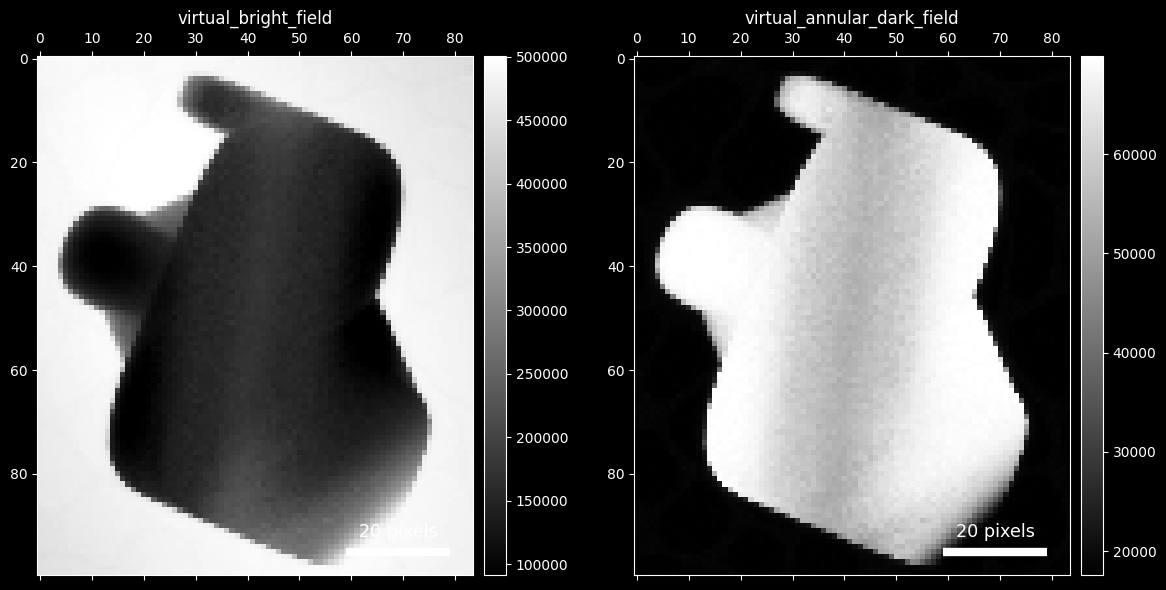

In [ ]:
if RUN_BASIC_VISUALIZATION:
    r_mean, x_mean, y_mean = datacube.get_probe_size(
        dp=datacube.get_dp_mean().data,
        plot=SHOW_FIGS,
        title="Probe size from mean DP",
    )

    print("probe radius:", r_mean)
    print("origin x0:", x_mean)
    print("origin y0:", y_mean)

    center = (x_mean, y_mean)
    radius = r_mean

    if SHOW_FIGS:
        datacube.position_detector(mode="circle", geometry=(center, radius), title="Probe position on mean DP")
        datacube.position_detector(data=datacube.get_dp_max().data, mode="circle", geometry=(center, radius), title="Probe position on max DP")

    vadf = datacube.get_virtual_image(
        mode="annulus",
        geometry=((x_mean, y_mean), (r_mean * 1.5, r_mean * 3.0)),
        name="virtual_annular_dark_field",
    )

    vbf = datacube.get_virtual_image(
        mode="circle",
        geometry=((x_mean, y_mean), r_mean),
        name="virtual_bright_field",
    )

    if SHOW_FIGS:
        py4DSTEM.show([vbf, vadf], title=[vbf.name, vadf.name], show_cbar=True,scaling="log")

print_calibration_report(datacube, "target datacube after basic visualization")




## 5. Probe / kernel preparation



Using vacuum_probe from file: <class 'py4DSTEM.data.diffractionslice.DiffractionSlice'>
probe alpha/radius: 5.167596991985157
probe center: 62.33260281660785 62.35873813884001


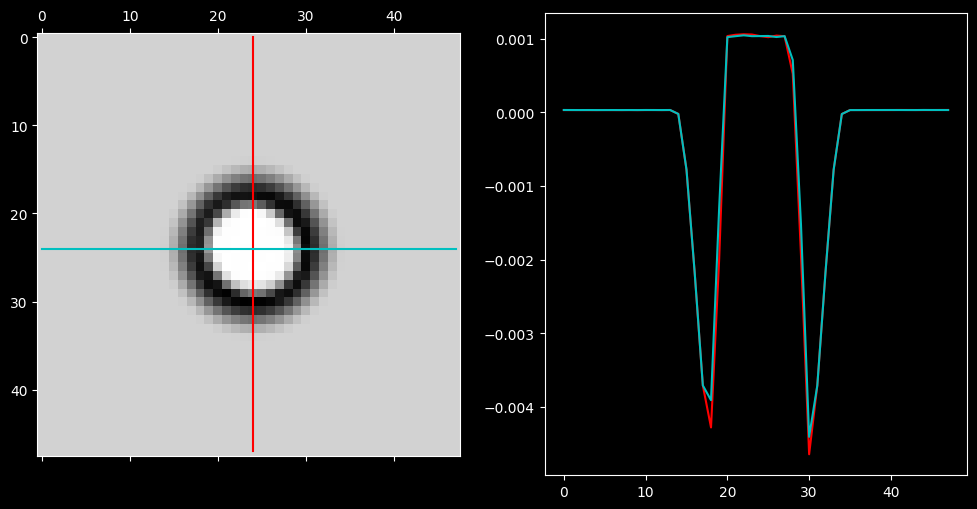

In [ ]:
def prepare_probe(root_obj, dc_obj, vbf_img=None):
    if not USE_PROBE_FROM_FILE and VACUUM_PROBE_NAME and exists_tree(root_obj, VACUUM_PROBE_NAME):
        vacuum_probe_obj = tree_get(root_obj, VACUUM_PROBE_NAME)
        print("Using vacuum_probe from file:", type(vacuum_probe_obj))

        # In some datasets this is a DiffractionSlice rather than Probe.
        if hasattr(py4DSTEM, "Probe") and hasattr(vacuum_probe_obj, "data") and not hasattr(vacuum_probe_obj, "get_kernel"):
            probe_obj = py4DSTEM.Probe(vacuum_probe_obj.data, name="probe")
        else:
            probe_obj = vacuum_probe_obj
    else:
        print("Using ROI from target datacube to estimate vacuum probe.")
        vacuum_probe_roi = np.zeros(dc_obj.Rshape, dtype=bool)
        vacuum_probe_roi[VACUUM_PROBE_ROI_SLICES] = True
        if SHOW_FIGS and vbf_img is not None:
            show(vbf_img, mask=~vacuum_probe_roi, mask_alpha=0.667, mask_color="r", title="Vacuum probe ROI")
        probe_obj = dc_obj.get_vacuum_probe(ROI=vacuum_probe_roi)

    alpha_pr, qx0_pr, qy0_pr = py4DSTEM.process.calibration.get_probe_size(probe_obj.probe)
    print("probe alpha/radius:", alpha_pr)
    print("probe center:", qx0_pr, qy0_pr)

    probe_obj.get_kernel(
        mode=PROBE_KERNEL_MODE,
        radii=(alpha_pr, PROBE_KERNEL_OUTER_FACTOR * alpha_pr),
    )
    return probe_obj, probe_obj.kernel


if RUN_PROBE_PREPARATION:
    probe, kernel = prepare_probe(root, datacube, vbf if 'vbf' in globals() else None)
    if SHOW_FIGS:
        py4DSTEM.visualize.show_kernel(probe.kernel, R=SHOW_KERNEL_R, L=SHOW_KERNEL_R, W=1)




## 6. Bragg disk detection diagnostics



scan position: 50 42
detected peaks: 33


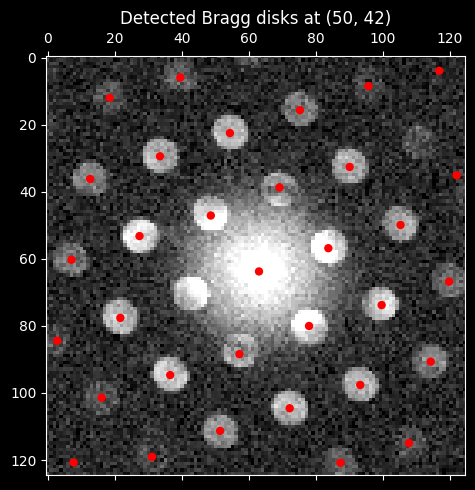

In [7]:
if RUN_SINGLE_POSITION_TEST:
    _ = find_bragg_disks_for_datacube(datacube, kernel, full=False)




In [8]:
if RUN_SELECTED_POSITION_TEST:
    R_Nx, R_Ny = datacube.Rshape
    rxs, rys = SELECTED_RXS, SELECTED_RYS
    print("selected positions:", rxs, rys)

    if SHOW_FIGS:
        py4DSTEM.visualize.show_points(vbf, x=rxs, y=rys, pointcolor=SELECTED_COLORS, figsize=(8, 8))
        py4DSTEM.visualize.show_image_grid(
            get_ar=lambda i: datacube[rxs[i], rys[i], :, :],
            H=2,
            W=3,
            axsize=(5, 5),
            intensity_range="absolute",
            vmin=10,
            vmax=500,
            scaling="power",
            power=0.5,
            get_bordercolor=lambda i: SELECTED_COLORS[i],
        )

    disks_selected = datacube.find_Bragg_disks(data=(rxs, rys), template=kernel, **BRAGG_DETECT_PARAMS)

    if SHOW_FIGS:
        py4DSTEM.visualize.show_image_grid(
            get_ar=lambda i: datacube[rxs[i], rys[i], :, :],
            H=2,
            W=3,
            axsize=(5, 5),
            intensity_range="absolute",
            vmin=10,
            vmax=500,
            scaling="power",
            power=0.5,
            get_bordercolor=lambda i: SELECTED_COLORS[i],
            get_x=lambda i: disks_selected[i].data["qx"],
            get_y=lambda i: disks_selected[i].data["qy"],
            get_pointcolors=lambda i: SELECTED_COLORS[i],
            open_circles=True,
            scale=700,
        )




## 7. Full Bragg disk detection on target



Finding Bragg Disks: 100%|██████████| 8.40k/8.40k [00:09<00:00, 845DP/s]


braggvectors type: <class 'py4DSTEM.braggvectors.braggvectors.BraggVectors'>
target cube origin: None
target braggvectors origin: None


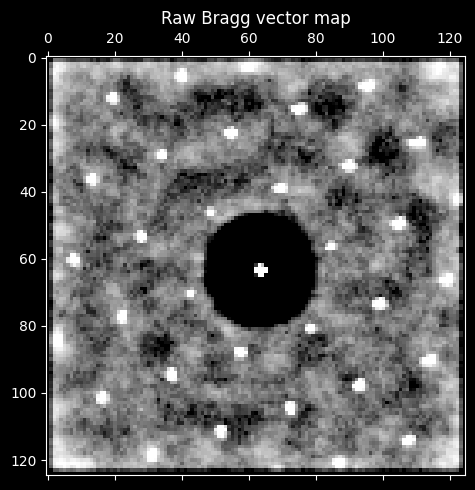


===== Calibration report: target braggvectors after detection =====
R pixel size: 1
R pixel units: pixels
Q pixel size: 1
Q pixel units: pixels
origin: None
ellipse: None
QR rotation / rotflip: None
calstate: {'center': False, 'ellipse': False, 'pixel': False, 'rotate': False}
flags: {'origin': False, 'q_pixel': True, 'ellipse': False, 'rotation': False}


In [9]:
if RUN_FULL_BRAGG_DETECTION:
    braggvectors = find_bragg_disks_for_datacube(datacube, kernel, name="braggvectors", full=True)
    print("target cube origin:", get_origin(datacube))
    print("target braggvectors origin:", get_origin(braggvectors))
    braggvectors.setcal(center=False, ellipse=False, pixel=False, rotate=False)
    bvm_raw = braggvectors.histogram(mode="raw")
    if SHOW_FIGS:
        py4DSTEM.show(bvm_raw, title="Raw Bragg vector map", scaling="log")

print_calibration_report(braggvectors, "target braggvectors after detection")




## 8. Optional: calibrate polycrystalline standard
用 poly standard 的目的：得到更可靠的 `Q pixel size + ellipse`。
目标数据仍建议单独拟合 origin。



In [ ]:
poly_braggvectors = get_existing_poly_braggvectors()
crystal_for_calibration = None

if RUN_CALIBRATION and CALIBRATION_STRATEGY in ("poly_transfer", "mixed"):
    print("\n===== Poly standard calibration =====")
    poly_braggvectors = calibrate_poly_standard(
        poly_dc_obj=poly_datacube if 'poly_datacube' in globals() else None,
        kernel_obj=kernel if 'kernel' in globals() else None,
        existing_bvs=poly_braggvectors,
    )




## 9. Target calibration



In [ ]:
if RUN_CALIBRATION:
    print("\n===== Target calibration =====")
    print_calibration_report(datacube, "target datacube before calibration")
    print_calibration_report(braggvectors, "target braggvectors before calibration")

    # 9.1 Always fit/measure target origin unless you explicitly trust existing origin.
    if CALIBRATION_STRATEGY != "read_existing":
        if DO_TARGET_MEASURE_ORIGIN:
            print("Measuring target origin...")
            qx0_meas, qy0_meas, mask_meas = braggvectors.measure_origin()
            if SHOW_FIGS:
                show([qx0_meas, qy0_meas], cmap="RdBu", mask=mask_meas, show_cbar=True,
                     title=["target qx0 measured", "target qy0 measured"])
        if DO_TARGET_FIT_ORIGIN:
            print("Fitting target origin...")
            braggvectors.fit_origin()

    # 9.2 Transfer Q pixel size / ellipse from poly standard when available.
    if CALIBRATION_STRATEGY in ("poly_transfer", "mixed") and poly_braggvectors is not None:
        print("Transferring selected calibration values from poly to target datacube and BraggVectors...")
        copy_calibration_values(
            source=poly_braggvectors,
            target=datacube,
            q_pixel_size=TRANSFER_Q_PIXEL_SIZE,
            q_pixel_units=True,
            ellipse=TRANSFER_ELLIPSE,
            origin=TRANSFER_ORIGIN,
            rotation=TRANSFER_ROTATION,
            verbose=True,
        )
        sync_datacube_to_braggvectors(datacube, braggvectors, transfer_origin=False, transfer_rotation=TRANSFER_ROTATION)

        # Keep target fitted origin if available; do not overwrite with datacube origin.
        if has_origin(braggvectors.calibration):
            print("Keeping target BraggVectors origin fitted from target data.")

    # 9.3 Direct ellipse/Q calibration from target, only if enabled.
    if CALIBRATION_STRATEGY in ("target_direct", "mixed"):
        if DO_TARGET_FIT_ELLIPSE:
            p_ellipse_target = fit_ellipse_from_bvm(braggvectors, TARGET_ELLIPSE_Q_RANGE, label="target")
            set_ellipse(datacube.calibration, p_ellipse_target)

        if DO_TARGET_CALIBRATE_Q_PIXEL:
            calibrate_q_pixel_from_crystal(
                braggvectors,
                get_reference_crystal_for_calibration(),
                label="target",
                q_pixel_guess=Q_PIXEL_SIZE_GUESS,
                q_units=Q_PIXEL_UNITS,
                k_max=K_MAX,
                bragg_k_power=2.0,
            )
            set_q_pixel(datacube.calibration, get_q_pixel_size(braggvectors), get_q_pixel_units(braggvectors))

    # 9.4 Optional manual QR rotation.
    if DO_SET_QR_ROTATION_MANUAL:
        if 'defocused_cbed' in globals() and defocused_cbed is not None and 'vbf' in globals() and SHOW_FIGS:
            py4DSTEM.process.calibration.compare_QR_rotation(
                vbf,
                defocused_cbed,
                QR_ROTATION_DEGREES,
            )
        set_qr_rotation_degrees(datacube.calibration, QR_ROTATION_DEGREES)
        set_qr_rotation_degrees(braggvectors.calibration, QR_ROTATION_DEGREES)

    print_calibration_report(datacube, "target datacube after calibration")
    print_calibration_report(braggvectors, "target braggvectors after calibration")

    # 9.5 Apply calibration flags for analysis.
    flags = apply_setcal(braggvectors, ANALYSIS_TARGET)

    if SHOW_FIGS:
        compare_raw_cal_bvm(braggvectors, label="target", sampling=BVM_SAMPLING)

print_fcc_q_values(A_LAT)




## 10. ACOM orientation analysis



Using manual fcc reference crystal.
Automatically detected point group m-3m,
 using arguments: zone_axis_range = 
[[0 1 1]
 [1 1 1]], 
 fiber_axis=None, fiber_angles=None.


Orientation plan: 100%|██████████| 406/406 [00:00<00:00, 16916.55 zone axes/s]
bragg peaks not rotationally calibrated
Generating orientation maps: 100%|██████████| 8400/8400 [00:00<00:00, 49411.60 PointList/s]


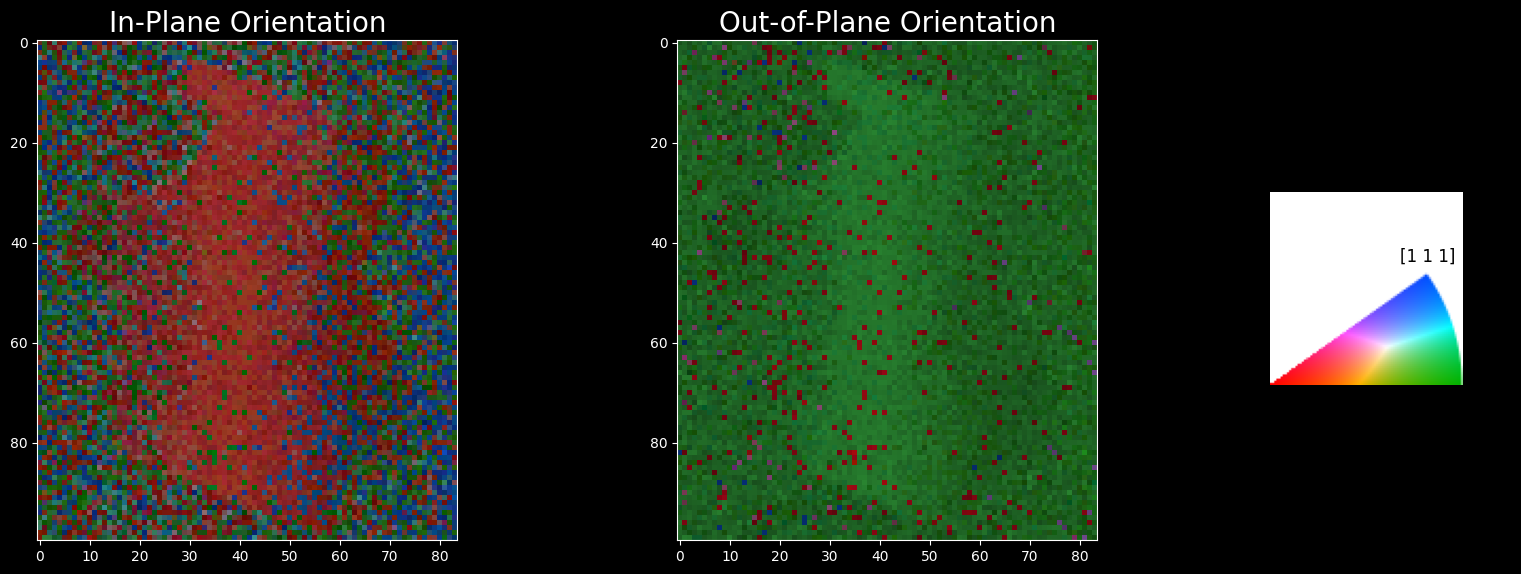

In [12]:
def prepare_acom_crystal():
    crystal_obj = build_reference_crystal(use_cif=USE_CIF_FOR_ACOM, cif_path=CIF_PATH)

    try:
        crystal_obj.setup_diffraction(accelerating_voltage=ACCEL_VOLTAGE)
    except Exception as exc:
        print("setup_diffraction skipped/failed:", repr(exc))

    calculate_structure_factors_if_needed(crystal_obj, K_MAX)

    # orientation_plan signature differs slightly across versions, so use fallback.
    plan_kwargs = dict(
        zone_axis_range=ZONE_AXIS_RANGE,
        angle_step_zone_axis=ANGLE_STEP_ZONE_AXIS,
        angle_step_in_plane=ANGLE_STEP_IN_PLANE,
        accel_voltage=ACCEL_VOLTAGE,
        corr_kernel_size=CORR_KERNEL_SIZE,
        sigma_excitation_error=SIGMA_EXCITATION_ERROR,
        power_radial=POWER_RADIAL,
        power_intensity=POWER_INTENSITY,
        power_intensity_experiment=POWER_INTENSITY_EXPERIMENT,
        CUDA=CUDA,
        progress_bar=True,
    )

    try:
        crystal_obj.orientation_plan(**plan_kwargs)
    except TypeError as exc:
        print("orientation_plan with power_intensity_experiment failed; retrying without it.")
        plan_kwargs.pop("power_intensity_experiment", None)
        crystal_obj.orientation_plan(**plan_kwargs)
    except Exception as exc:
        if ZONE_AXIS_RANGE == "auto":
            print("orientation_plan with zone_axis_range='auto' failed; retrying with 'full'.")
            plan_kwargs["zone_axis_range"] = "full"
            crystal_obj.orientation_plan(**plan_kwargs)
        else:
            raise

    return crystal_obj


if RUN_ACOM_ORIENTATION:
    if ANALYSIS_TARGET.lower() not in ("acom", "orientation", "orientation_map"):
        print("ANALYSIS_TARGET is not ACOM, but RUN_ACOM_ORIENTATION=True. Applying ACOM setcal now.")
        apply_setcal(braggvectors, "ACOM")

    crystal = prepare_acom_crystal()

    orientation_map = crystal.match_orientations(
        braggvectors,
        num_matches_return=NUM_MATCHES_RETURN,
        min_angle_between_matches_deg=MIN_ANGLE_BETWEEN_MATCHES_DEG,
        min_number_peaks=MIN_NUMBER_PEAKS,
        inversion_symmetry=INVERSION_SYMMETRY,
        progress_bar=True,
    )

    for i in range(NUM_MATCHES_RETURN):
        crystal.plot_orientation_maps(
            orientation_map=orientation_map,
            orientation_ind=i,
            corr_range=CORR_RANGE,
            corr_normalize=True,
            figsize=(16, 5),
            show_axes=True,
            progress_bar=True,
        )




## 11. Save outputs / export `.ang`



In [13]:
if RUN_SAVE_RESULTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    if SAVE_BRAGGVECTORS_PICKLE and 'braggvectors' in globals():
        out = OUTPUT_DIR / "braggvectors.pkl"
        with open(out, "wb") as f:
            pickle.dump(braggvectors, f)
        print("Saved:", out)

    if SAVE_ORIENTATION_PICKLE and 'orientation_map' in globals():
        out = OUTPUT_DIR / "orientation_map.pkl"
        with open(out, "wb") as f:
            pickle.dump(orientation_map, f)
        print("Saved:", out)

    if SAVE_ANG_FILE and 'orientation_map' in globals() and 'crystal' in globals():
        try:
            out = OUTPUT_DIR / "orientation_map.ang"
            crystal.save_ang_file(
                file_name=str(out),
                orientation_map=orientation_map,
                ind_orientation=0,
                pixel_size=ANG_PIXEL_SIZE,
                pixel_units=ANG_PIXEL_UNITS,
                transpose_xy=True,
                flip_x=False,
                flip_y=False,
            )
            print("Saved:", out)
        except Exception as exc:
            print("ANG export failed. Install orix if needed: conda install -c conda-forge orix")
            print("Error:", repr(exc))




Saved: py4dstem_outputs\braggvectors.pkl
Saved: py4dstem_outputs\orientation_map.pkl


In [15]:
braggvectors.calibration

Calibration( A Metadata instance called 'calibration', containing the following fields:

             Q_pixel_size:       0.01132059874420398
             R_pixel_size:       1
             Q_pixel_units:      A^-1
             R_pixel_units:      pixels
             QR_flip:            False
             _target_paths:      ['/4DSTEM_polyAu']
             probe_semiangle:    5.113302983166629
             qx0_mean:           64.43428373073819
             qy0_mean:           64.13718322140487
             qx0_meas:           2D-array
             qy0_meas:           2D-array
             origin_meas_mask:   2D-array
             qx0:                2D-array
             qx0_shift:          2D-array
             qy0:                2D-array
             qy0_shift:          2D-array
             a:                  333.6873708100986
             b:                  327.3339695447527
             theta:              -2.2384213140896607
)

## 12. Optional strain map
注意：strain map 的物理解释比 orientation map 更依赖 calibration。
正式解释 strain 前建议具备：
- origin
- Q pixel size
- ellipse
- QR rotation
- 合理的 reference ROI / reference g1,g2



Continuing only if you intentionally accept semi-quantitative strain output.


Strain mapping strongly requires: QR rotation


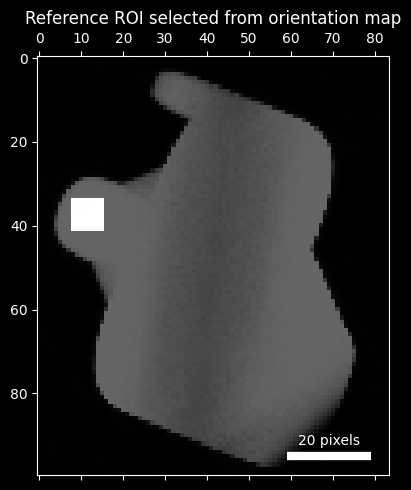

Real to reciprocal space rotation not calibrated


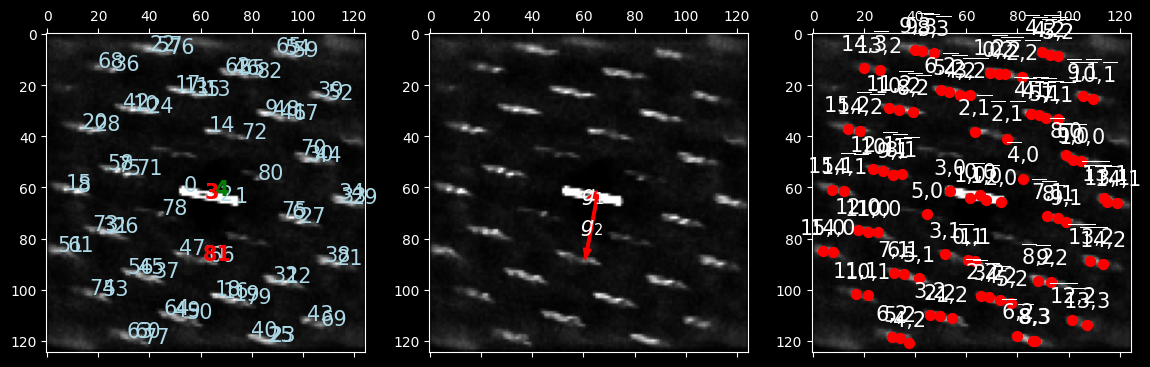

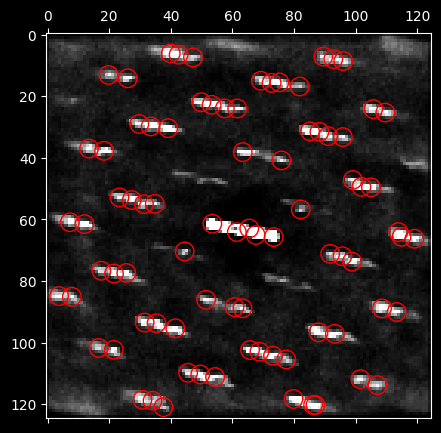

Indexing Bragg scattering: 100%|██████████| 8.40k/8.40k [00:02<00:00, 3.20kDP/s]
Fitting lattice vectors: 100%|██████████| 8.40k/8.40k [00:01<00:00, 8.25kDP/s]


Reference mode: roi_vectors; ROI pixels: 64
g1_ref: (1.0965810186330383, -3.934291787278829)
g2_ref: (24.091528326267106, -4.716995538331904)


Calculating strain: 100%|██████████| 8.40k/8.40k [00:01<00:00, 8.26kDP/s]


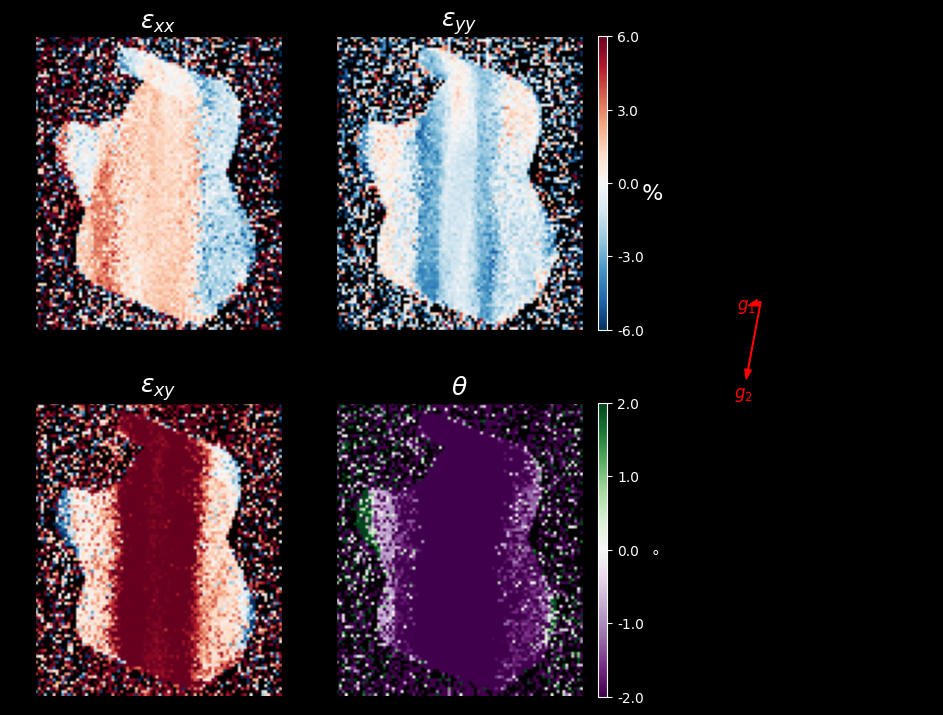

In [16]:
RUN_STRAIN_OPTIONAL = True
if RUN_STRAIN_OPTIONAL:
    # Make sure strain-level calibration is active.
    try:
        apply_setcal(braggvectors, "strain")
    except RuntimeError as exc:
        warnings.warn(str(exc))
        print("Continuing only if you intentionally accept semi-quantitative strain output.")

    strain_ref_roi = np.zeros(datacube.Rshape, dtype=bool)
    strain_ref_roi[STRAIN_REF_ROI_SLICES] = True

    if SHOW_FIGS and 'vadf' in globals():
        show(vadf, mask=strain_ref_roi, mask_alpha=0.4, title="Reference ROI selected from orientation map")

    strainmap = py4DSTEM.StrainMap(braggvectors=braggvectors)

    strainmap.choose_basis_vectors(
        minSpacing=2,
        minAbsoluteIntensity=1.2e3,
        maxNumPeaks=150,
        edgeBoundary=1,
        vis_params={"vmin": 0, "vmax": 0.995},
    )

    strainmap.set_max_peak_spacing(max_peak_spacing=3)
    strainmap.fit_basis_vectors()

    ROI = strain_ref_roi

    if STRAIN_REFERENCE_MODE == "auto_valid":
        valid = strainmap.g1g2_map.get_slice("mask").data.astype(bool)
        n_valid = int(valid.sum())
        print("Reference mode: auto_valid; valid fitted points:", n_valid)
        if n_valid == 0:
            raise RuntimeError("No valid g1/g2 fitted points. Adjust basis-vector selection.")
        gvects_for_strain = valid

    elif STRAIN_REFERENCE_MODE == "roi_mask":
        n_roi = int(ROI.sum())
        print("Reference mode: roi_mask; ROI pixels:", n_roi)
        if n_roi == 0:
            raise RuntimeError("ROI is empty.")
        gvects_for_strain = ROI

    elif STRAIN_REFERENCE_MODE == "roi_vectors":
        n_roi = int(ROI.sum())
        print("Reference mode: roi_vectors; ROI pixels:", n_roi)
        if n_roi == 0:
            raise RuntimeError("ROI is empty.")
        g1_ref, g2_ref = strainmap.get_reference_g1g2(ROI)
        print("g1_ref:", g1_ref)
        print("g2_ref:", g2_ref)
        gvects_for_strain = (g1_ref, g2_ref)

    elif STRAIN_REFERENCE_MODE == "manual":
        g1_ref = None
        g2_ref = None
        if g1_ref is None or g2_ref is None:
            raise RuntimeError("manual mode requires g1_ref and g2_ref.")
        gvects_for_strain = (g1_ref, g2_ref)

    else:
        raise ValueError("Unknown STRAIN_REFERENCE_MODE")

    strainmap.get_strain(
        gvects=gvects_for_strain,
        coordinate_rotation=STRAIN_COORDINATE_ROTATION,
        layout=STRAIN_LAYOUT,
        vrange=STRAIN_VRANGE,
        vrange_theta=THETA_VRANGE,
    )




## 13. Minimal downstream usage reminders
- `orientation_ind=0` 是最佳匹配取向；`orientation_ind=1/2` 是第二、第三候选取向。
- `num_matches_return=1` 通常用于最终图；`2/3` 通常用于诊断重叠晶粒或索引歧义。
- 如果 ACOM 图很乱，优先检查：Bragg disk detection、origin、Q pixel size、ellipse、晶体结构/晶格常数。
- 如果 strain 图有整体非物理梯度，优先检查：origin field、ellipse、QR rotation、reference ROI。
